# 06 — 1D-CNN Classification with 5-Fold Stratified Cross Validation

This notebook trains and evaluates a **1D Convolutional Neural Network (1D-CNN)** for binary
classification of NIR corn spectra (High-Protein vs Low-Protein) using
**5-Fold Stratified Cross Validation**.

The original `06_1d_cnn_training.ipynb` trained the model once on a fixed 80/20 split
(64 training, 16 test samples). With only 80 total samples, that single split is highly
sensitive to which samples happen to land in the test set — a one-sample shift changes
accuracy by ±6%. By training **five separate CNNs** — each on a different 64-sample fold —
and averaging the performance metrics, we obtain a more statistically reliable estimate
of model generalisation.

## Section 1 — Imports and Setup

We import all required libraries, add the project root to `sys.path` so that the `src/`
modules are importable, and fix every random seed to ensure full reproducibility across
runs. Setting seeds in Python's built-in `random`, NumPy, and TensorFlow ensures that
weight initialisation, data shuffling, and augmentation all produce the same outputs
each time the notebook is executed.

In [1]:
import sys
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Allow imports from the project root (src/ directory)
sys.path.append('../..')

from src.augmentor import interpolation_augment
from src.cnn_trainer import (
    build_1d_cnn,
    reshape_for_cnn,
    plot_training_history,
    plot_cnn_confusion_matrix,
)

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")
print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")

All libraries imported successfully.
TensorFlow version : 2.21.0
NumPy version      : 2.4.4


## Section 2 — Load Full Dataset

We load the Savitzky–Golay preprocessed spectra (`X_preprocessed.npy`) and their
corresponding binary protein labels (`y_labels.npy`).

**All 80 samples are loaded and kept intact at this stage.** No train/test split is
performed here. The cross-validation loop in Section 4 is solely responsible for
partitioning the data — this ensures no bias is introduced by a manual split made
before cross-validation begins.

In [2]:
X = np.load('../../data/processed/X_preprocessed.npy')
y = np.load('../../data/processed/y_labels.npy')

print(f"X shape : {X.shape}  (samples x wavelengths)")
print(f"y shape : {y.shape}")
print()
print("Class distribution:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = "High-Protein (1)" if cls == 1 else "Low-Protein  (0)"
    print(f"  Class {int(cls)} — {label}: {cnt} samples")
print(f"\nTotal samples: {len(y)}")

X shape : (539, 700)  (samples x wavelengths)
y shape : (539,)

Class distribution:
  Class 0 — Low-Protein  (0): 250 samples
  Class 1 — High-Protein (1): 289 samples

Total samples: 539


## Section 3 — Define 5-Fold Stratified Cross Validation

`StratifiedKFold` divides the 80 samples into 5 folds of 16 samples each while
**preserving the class ratio** in every fold. With only 80 samples, a non-stratified
split could accidentally produce a test fold where one protein class is
over-represented, which would bias the accuracy and F1-score for that fold.
Stratification guarantees that each fold is a representative mini-version of
the full dataset.

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("5-Fold Stratified Cross Validation configured.")
print(f"  n_splits     : {skf.n_splits}")
print(f"  shuffle      : {skf.shuffle}")
print(f"  random_state : {skf.random_state}")
print(f"\nEach fold: ~{len(y) // skf.n_splits} test samples, "
      f"~{len(y) - len(y) // skf.n_splits} training samples")

5-Fold Stratified Cross Validation configured.
  n_splits     : 5
  shuffle      : True
  random_state : 42

Each fold: ~107 test samples, ~432 training samples


## Section 4 — 1D-CNN 5-Fold Cross Validation

The following loop trains a **completely fresh 1D-CNN** for each of the five folds.
All preprocessing steps occur strictly within the loop so that no information from
any test fold can influence the training process:

1. **Split** — 64 training samples and 16 test samples (stratified).
2. **Real validation set** — Before augmentation, ~8 real spectra are held out
   from the 64-sample training fold using `StratifiedShuffleSplit`. These are
   passed as `validation_data` to `model.fit()` so that `EarlyStopping` monitors
   loss on **genuine, unseen spectra** — not on synthetic samples. Using
   `validation_split=0.1` on the augmented set would mean 200 synthetic spectra
   as the validation set, which are highly correlated with training and would
   prevent early stopping from ever triggering.
3. **Augmentation** — `interpolation_augment` expands the remaining ~56 training
   spectra to 2,000 synthetic samples. The validation and test folds are never
   augmented.
4. **Scaling** — `StandardScaler` is *fitted exclusively on the 2,000 augmented
   training samples* and then used to transform the validation and test sets.
5. **Reshape** — `reshape_for_cnn` adds the channel dimension required by
   Conv1D: `(n_samples, 700)` → `(n_samples, 700, 1)`.
6. **Training** — Up to 100 epochs, batch size 64. `EarlyStopping` (patience = 20)
   monitors `val_loss` on the real validation set and restores the best weights.
7. **Best model tracking** — The fold that produces the **highest F1-score**
   on its test fold is retained as the final best model.


  Fold 1 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  For augmentation : 377 samples
  Real validation  : 54 samples (used by EarlyStopping)
Interpolation Augmentation
Original training size          : 377
Synthetic samples to generate   : 1623
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 952 samples
  1 (High Protein): 1048 samples
  Augmented        : 2000 training samples after augmentation


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.6240 - loss: 0.7094 - val_accuracy: 0.5556 - val_loss: 0.6788
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6930 - loss: 0.5910 - val_accuracy: 0.5556 - val_loss: 0.6813
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7115 - loss: 0.5595 - val_accuracy: 0.5741 - val_loss: 0.6748
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7245 - loss: 0.5398 - val_accuracy: 0.5741 - val_loss: 0.6842
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7280 - loss: 0.5497 - val_accuracy: 0.5741 - val_loss: 0.6803
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7330 - loss: 0.5513 - val_accuracy: 0.5741 - val_loss: 0.6516
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7445 - loss: 0.5198 - val_accuracy: 0.5926 - val_loss: 0.6519
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7460 - loss: 0.5082 - val_accuracy: 0.

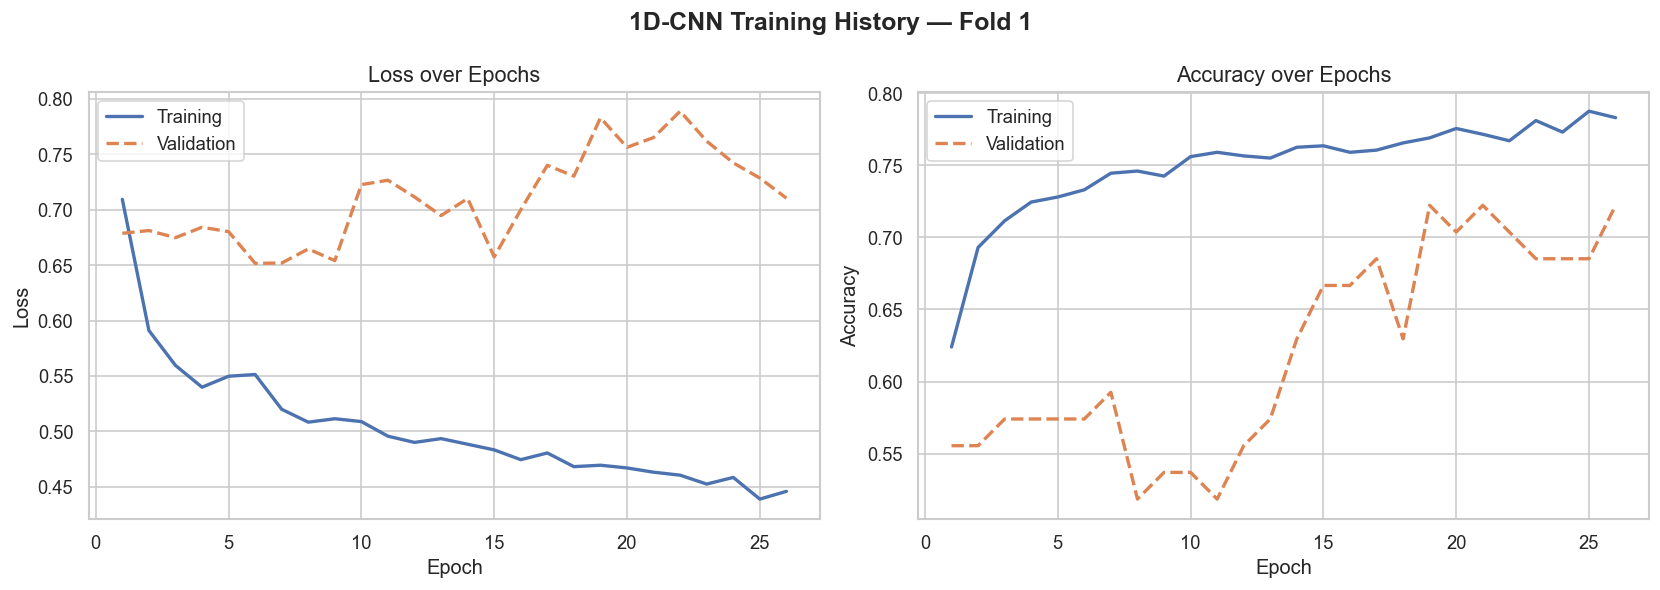

Fold 1: Accuracy=0.5370  Precision=0.7500  Recall=0.2069  F1=0.3243
  *** New best model (Fold 1, F1 = 0.3243) ***

  Fold 2 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  For augmentation : 377 samples
  Real validation  : 54 samples (used by EarlyStopping)
Interpolation Augmentation
Original training size          : 377
Synthetic samples to generate   : 1623
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 952 samples
  1 (High Protein): 1048 samples
  Augmented        : 2000 training samples after augmentation


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.6615 - loss: 0.6586 - val_accuracy: 0.5556 - val_loss: 0.6788
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7040 - loss: 0.5848 - val_accuracy: 0.5185 - val_loss: 0.6734
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7160 - loss: 0.5673 - val_accuracy: 0.6852 - val_loss: 0.6586
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7210 - loss: 0.5513 - val_accuracy: 0.5926 - val_loss: 0.6695
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7195 - loss: 0.5437 - val_accuracy: 0.6481 - val_loss: 0.6547
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7440 - loss: 0.5238 - val_accuracy: 0.7407 - val_loss: 0.6151
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7425 - loss: 0.5211 - val_accuracy: 0.7407 - val_loss: 0.5904
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7460 - loss: 0.5203 - val_accuracy: 0.

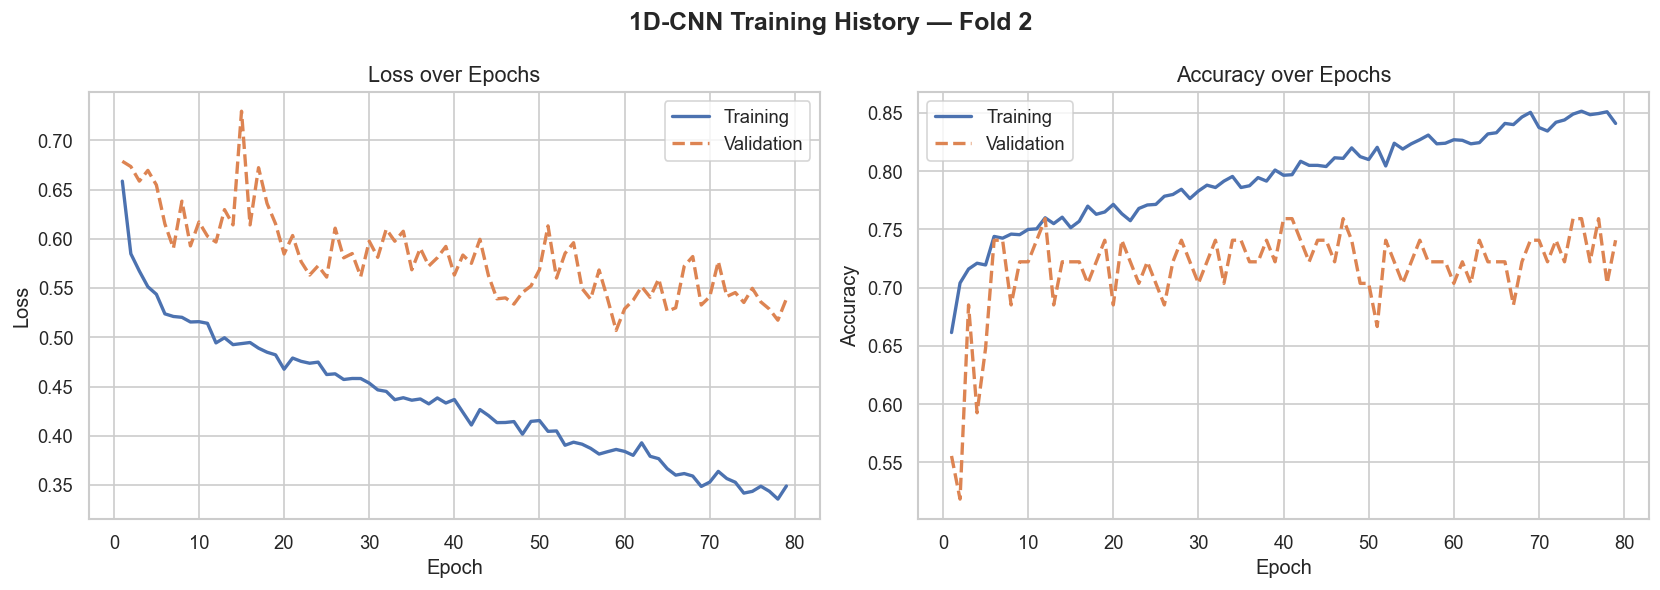

Fold 2: Accuracy=0.8241  Precision=0.8095  Recall=0.8793  F1=0.8430
  *** New best model (Fold 2, F1 = 0.8430) ***

  Fold 3 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  For augmentation : 377 samples
  Real validation  : 54 samples (used by EarlyStopping)
Interpolation Augmentation
Original training size          : 377
Synthetic samples to generate   : 1623
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 952 samples
  1 (High Protein): 1048 samples
  Augmented        : 2000 training samples after augmentation


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6640 - loss: 0.6788 - val_accuracy: 0.5000 - val_loss: 0.6944
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7125 - loss: 0.5998 - val_accuracy: 0.6481 - val_loss: 0.6695
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7235 - loss: 0.5667 - val_accuracy: 0.6111 - val_loss: 0.6689
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7255 - loss: 0.5401 - val_accuracy: 0.6296 - val_loss: 0.6545
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7220 - loss: 0.5505 - val_accuracy: 0.6481 - val_loss: 0.6591
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7300 - loss: 0.5305 - val_accuracy: 0.6481 - val_loss: 0.6518
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7460 - loss: 0.5226 - val_accuracy: 0.6667 - val_loss: 0.5960
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7405 - loss: 0.5178 - val_accuracy: 0.

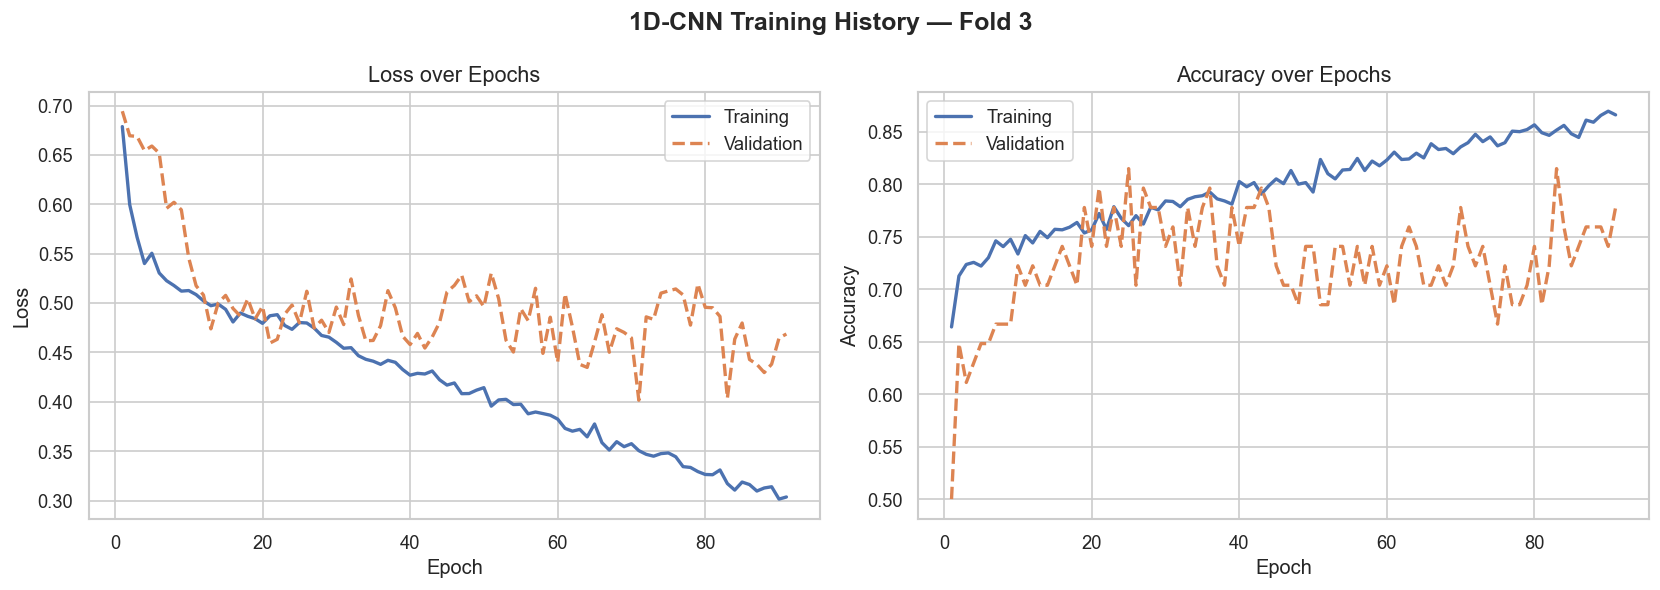

Fold 3: Accuracy=0.7963  Precision=0.8214  Recall=0.7931  F1=0.8070

  Fold 4 / 5
  Train fold : 431 samples
  Test fold  : 108 samples
  For augmentation : 377 samples
  Real validation  : 54 samples (used by EarlyStopping)
Interpolation Augmentation
Original training size          : 377
Synthetic samples to generate   : 1623
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 952 samples
  1 (High Protein): 1048 samples
  Augmented        : 2000 training samples after augmentation


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6885 - loss: 0.6778 - val_accuracy: 0.5185 - val_loss: 0.6868
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7090 - loss: 0.5864 - val_accuracy: 0.5370 - val_loss: 0.6723
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7255 - loss: 0.5539 - val_accuracy: 0.5556 - val_loss: 0.6656
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7285 - loss: 0.5375 - val_accuracy: 0.5926 - val_loss: 0.6503
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7280 - loss: 0.5455 - val_accuracy: 0.5556 - val_loss: 0.6705
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7425 - loss: 0.5315 - val_accuracy: 0.5556 - val_loss: 0.6753
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7435 - loss: 0.5188 - val_accuracy: 0.5370 - val_loss: 0.6817
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7380 - loss: 0.5171 - val_accuracy: 0.

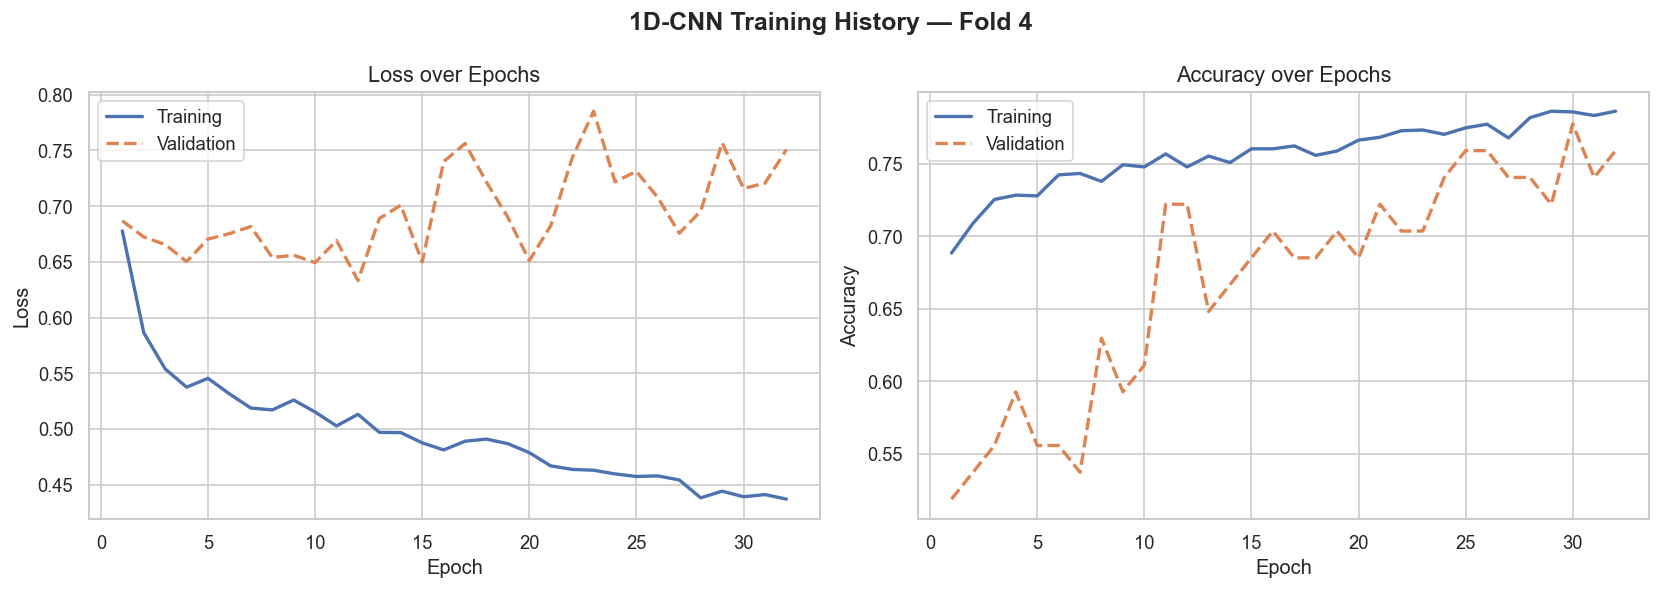

Fold 4: Accuracy=0.7500  Precision=0.7460  Recall=0.8103  F1=0.7769

  Fold 5 / 5
  Train fold : 432 samples
  Test fold  : 107 samples
  For augmentation : 378 samples
  Real validation  : 54 samples (used by EarlyStopping)
Interpolation Augmentation
Original training size          : 378
Synthetic samples to generate   : 1622
Final training size after augmentation : 2000

Class distribution after augmentation:
  0 (Low Protein): 908 samples
  1 (High Protein): 1092 samples
  Augmented        : 2000 training samples after augmentation


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6925 - loss: 0.6401 - val_accuracy: 0.6481 - val_loss: 0.6514
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7210 - loss: 0.5593 - val_accuracy: 0.6667 - val_loss: 0.6329
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7230 - loss: 0.5637 - val_accuracy: 0.7222 - val_loss: 0.6104
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7280 - loss: 0.5268 - val_accuracy: 0.6296 - val_loss: 0.6350
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7450 - loss: 0.5226 - val_accuracy: 0.6667 - val_loss: 0.6109
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7325 - loss: 0.5337 - val_accuracy: 0.7407 - val_loss: 0.5699
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7350 - loss: 0.5318 - val_accuracy: 0.7222 - val_loss: 0.5574
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7435 - loss: 0.5125 - val_accuracy: 0.

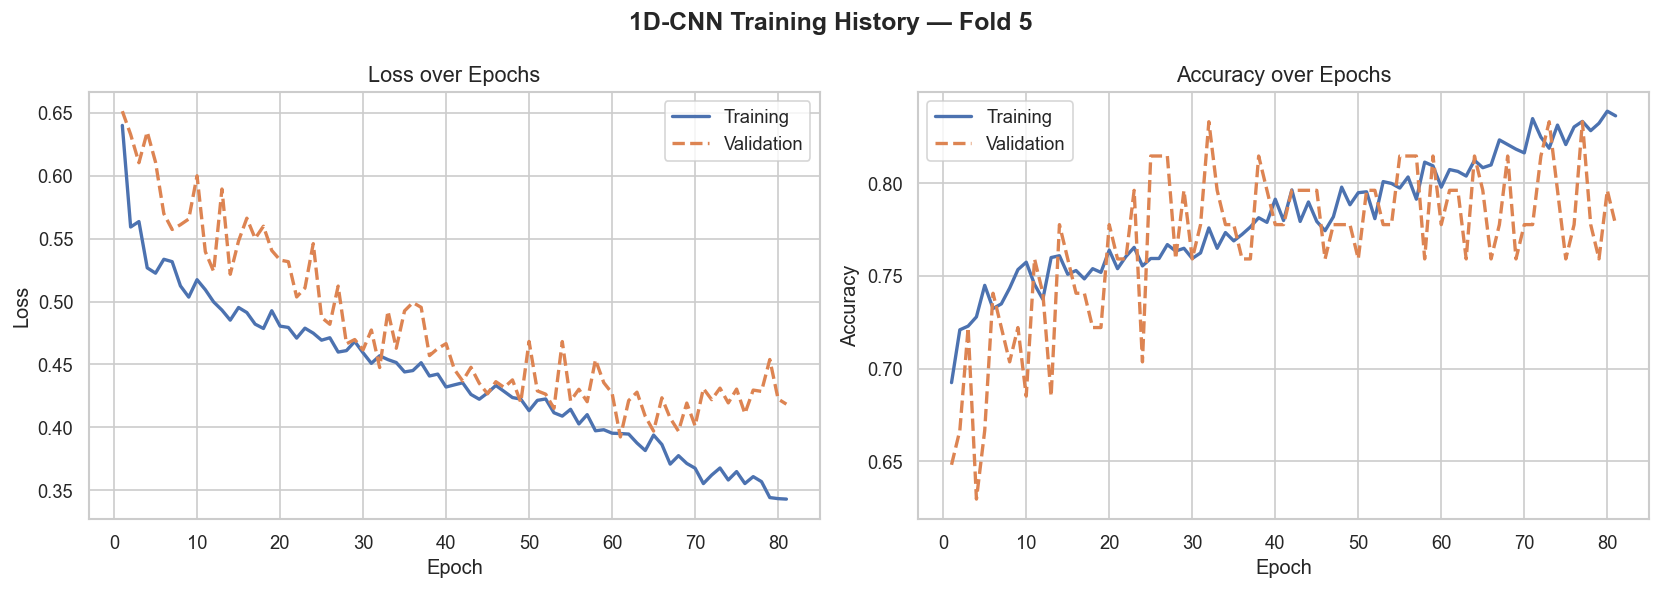

Fold 5: Accuracy=0.7570  Precision=0.7313  Recall=0.8596  F1=0.7903

Cross-validation complete.
Best fold F1-score : 0.8430


In [4]:
os.makedirs('../../saved_models/revised', exist_ok=True)

# ── Storage for per-fold results ──────────────────────────────────────────────
cnn_fold_metrics = []
cnn_best_model   = None
cnn_best_scaler  = None
cnn_best_f1      = 0.0
cnn_all_y_true   = []
cnn_all_y_pred   = []

# ── 5-Fold Cross Validation Loop ──────────────────────────────────────────────
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    print(f"\n{'='*56}")
    print(f"  Fold {fold + 1} / {skf.n_splits}")
    print(f"{'='*56}")

    # ── 1. Split into training fold and test fold ─────────────────────────────
    X_train_fold = X[train_idx]
    X_test_fold  = X[test_idx]
    y_train_fold = y[train_idx]
    y_test_fold  = y[test_idx]

    print(f"  Train fold : {X_train_fold.shape[0]} samples")
    print(f"  Test fold  : {X_test_fold.shape[0]} samples")

    # ── 2. Carve out a real validation set BEFORE augmentation ────────────────
    #    Using real spectra for EarlyStopping ensures the stopping criterion
    #    reflects genuine generalisation — not performance on synthetic samples.
    #    ~12.5 % of 64 → 8 real validation samples; remaining 56 are augmented.
    val_splitter = StratifiedShuffleSplit(
        n_splits=1, test_size=0.125, random_state=RANDOM_STATE
    )
    aug_idx, val_idx = next(val_splitter.split(X_train_fold, y_train_fold))

    X_train_sub = X_train_fold[aug_idx]
    y_train_sub = y_train_fold[aug_idx]
    X_val_real  = X_train_fold[val_idx]
    y_val_real  = y_train_fold[val_idx]

    print(f"  For augmentation : {X_train_sub.shape[0]} samples")
    print(f"  Real validation  : {X_val_real.shape[0]} samples (used by EarlyStopping)")

    # ── 3. Augment the training sub-split only ────────────────────────────────
    X_aug, y_aug = interpolation_augment(
        X_train_sub, y_train_sub,
        target_total=2000,
        random_state=RANDOM_STATE,
    )
    print(f"  Augmented        : {X_aug.shape[0]} training samples after augmentation")

    # ── 4. Scale — fit on augmented training data only ────────────────────────
    scaler         = StandardScaler()
    X_aug_scaled   = scaler.fit_transform(X_aug)
    X_val_scaled   = scaler.transform(X_val_real)
    X_test_scaled  = scaler.transform(X_test_fold)

    # ── 5. Reshape for Conv1D: (n_samples, 700) -> (n_samples, 700, 1) ────────
    X_train_cnn = reshape_for_cnn(X_aug_scaled)
    X_val_cnn   = reshape_for_cnn(X_val_scaled)
    X_test_cnn  = reshape_for_cnn(X_test_scaled)

    # ── 6. Build a fresh CNN for this fold ────────────────────────────────────
    model = build_1d_cnn(input_length=700)

    ckpt_path = f'../../saved_models/revised/cnn_fold_{fold + 1}.keras'
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=0,
        ),
        ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=0,
        ),
    ]

    # ── 7. Train with real validation_data (not validation_split) ─────────────
    history = model.fit(
        X_train_cnn, y_aug,
        epochs=100,
        batch_size=64,
        validation_data=(X_val_cnn, y_val_real),
        callbacks=callbacks,
        verbose=1,
    )
    print(f"Fold {fold + 1} stopped at epoch {len(history.history['loss'])}")

    # ── 8. Plot training history for this fold ────────────────────────────────
    plot_training_history(history, title=f'1D-CNN Training History — Fold {fold + 1}')
    plt.show()

    # ── 9. Predict on the untouched test fold ─────────────────────────────────
    y_prob = model.predict(X_test_cnn, verbose=0)[:, 0]
    y_pred = (y_prob >= 0.5).astype(int)

    # ── 10. Compute metrics ───────────────────────────────────────────────────
    acc  = accuracy_score(y_test_fold, y_pred)
    prec = precision_score(y_test_fold, y_pred, zero_division=0)
    rec  = recall_score(y_test_fold, y_pred, zero_division=0)
    f1   = f1_score(y_test_fold, y_pred, zero_division=0)

    print(f"Fold {fold + 1}: Accuracy={acc:.4f}  Precision={prec:.4f}  "
          f"Recall={rec:.4f}  F1={f1:.4f}")

    cnn_fold_metrics.append(
        {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    )
    cnn_all_y_true.append(y_test_fold)
    cnn_all_y_pred.append(y_pred)

    # ── 11. Track best model by F1-score ──────────────────────────────────────
    if f1 > cnn_best_f1:
        cnn_best_f1     = f1
        cnn_best_model  = model
        cnn_best_scaler = scaler  # save the scaler from this fold too
        print(f"  *** New best model (Fold {fold + 1}, F1 = {cnn_best_f1:.4f}) ***")

print(f"\nCross-validation complete.")
print(f"Best fold F1-score : {cnn_best_f1:.4f}")


## Section 5 — CNN Results Summary

We summarise performance across all five folds by computing the mean and standard
deviation of each metric. The **combined confusion matrix** is constructed by
concatenating the predictions from every test fold. Because each of the 80 samples
belongs to exactly one test fold, every sample appears in the combined matrix exactly
once — giving a complete and unbiased picture of model performance across the
full dataset without any data leakage.

  1D-CNN 5-Fold Cross Validation Results
  Accuracy  : 0.7329 +/- 0.1135
  Precision : 0.7717 +/- 0.0408
  Recall    : 0.7099 +/- 0.2834
  F1-Score  : 0.7083 +/- 0.2161

Per-fold breakdown:
   Accuracy  Precision    Recall  F1-Score
0  0.537037   0.750000  0.206897  0.324324
1  0.824074   0.809524  0.879310  0.842975
2  0.796296   0.821429  0.793103  0.807018
3  0.750000   0.746032  0.810345  0.776860
4  0.757009   0.731343  0.859649  0.790323


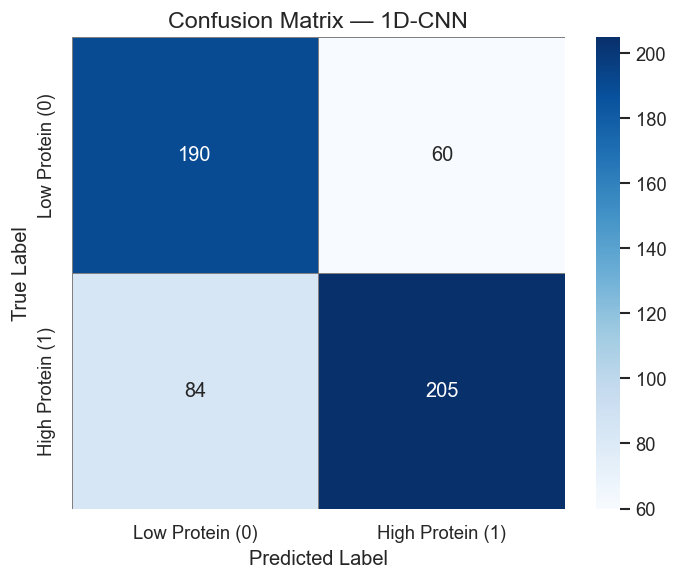

In [5]:
metrics_df = pd.DataFrame(cnn_fold_metrics)

mean_acc  = metrics_df['accuracy'].mean()
std_acc   = metrics_df['accuracy'].std()
mean_prec = metrics_df['precision'].mean()
std_prec  = metrics_df['precision'].std()
mean_rec  = metrics_df['recall'].mean()
std_rec   = metrics_df['recall'].std()
mean_f1   = metrics_df['f1'].mean()
std_f1    = metrics_df['f1'].std()

print("====================================================")
print("  1D-CNN 5-Fold Cross Validation Results")
print("====================================================")
print(f"  Accuracy  : {mean_acc:.4f} +/- {std_acc:.4f}")
print(f"  Precision : {mean_prec:.4f} +/- {std_prec:.4f}")
print(f"  Recall    : {mean_rec:.4f} +/- {std_rec:.4f}")
print(f"  F1-Score  : {mean_f1:.4f} +/- {std_f1:.4f}")
print("====================================================")

# ── Per-fold breakdown ────────────────────────────────────────────────────────
print("\nPer-fold breakdown:")
print(metrics_df.rename(columns={
    'accuracy': 'Accuracy', 'precision': 'Precision',
    'recall': 'Recall', 'f1': 'F1-Score',
}).to_string(index=True))

# ── Combined confusion matrix (all 80 samples, each exactly once) ─────────────
y_true_all = np.concatenate(cnn_all_y_true)
y_pred_all = np.concatenate(cnn_all_y_pred)

plot_cnn_confusion_matrix(y_true_all, y_pred_all)
plt.show()

## Save Best CNN Model (Bundled with Scaler)

The best CNN model is first saved as a .keras file then bundled together
with its StandardScaler and model_type into a single .pkl file. This
matches the same bundle format used by PLS-DA and SVM — making inference.py
consistent across all three models. The scaler must be saved because the
CNN was trained on StandardScaler-normalized spectra and any new input
must be normalized the same way before prediction.


In [6]:
import os
import joblib

os.makedirs('../../saved_models/revised', exist_ok=True)

# Step 1 — Save the Keras model weights to .keras file
keras_path = '../../saved_models/revised/1d_cnn_best.keras'
cnn_best_model.save(keras_path)
print(f"CNN model weights saved to: {keras_path}")

# Step 2 — Save bundle containing scaler + model_type + path to keras file
cnn_bundle = {
    'model_type': '1D-CNN',
    'scaler': cnn_best_scaler,
    'keras_path': keras_path,
}
joblib.dump(cnn_bundle, '../../saved_models/revised/1d_cnn_best.pkl')
print(f"CNN bundle saved to: saved_models/revised/1d_cnn_best.pkl")
print(f"Bundle contains: model_type + scaler + keras_path")
print(f"Best fold F1-score: {cnn_best_f1:.4f}")


CNN model weights saved to: ../../saved_models/revised/1d_cnn_best.keras
CNN bundle saved to: saved_models/revised/1d_cnn_best.pkl
Bundle contains: model_type + scaler + keras_path
Best fold F1-score: 0.8430


## Section 7 — Summary

| Item | Detail |
|---|---|
| **Evaluation method** | 5-Fold Stratified Cross Validation |
| **Each fold** | 64 training samples augmented to 2,000; 16 test samples kept as original unmodified spectra |
| **Preprocessing** | `StandardScaler` fitted *inside each fold* on augmented training data only — never on test data |
| **CNN architecture** | Conv1D(32, k=11) → BN → MaxPool → Conv1D(64, k=7) → BN → MaxPool → Dense(32) → Dropout(0.3) → Dense(1, sigmoid) |
| **Optimiser** | Adam (lr = 0.0001), loss = binary cross-entropy |
| **Training** | Up to 100 epochs, batch size 64, EarlyStopping patience = 20, restore_best_weights = True |
| **Metrics** | Accuracy, Precision, Recall, F1-Score — reported as mean +/- std across 5 folds |
| **Best model** | Fold with highest F1-score saved to `saved_models/revised/1d_cnn_best.keras` |
| **Next notebook** | `notebooks/revised/07_evaluation_metrics.ipynb` — head-to-head comparison of PLS-DA, SVM, and 1D-CNN |

### Key design decisions

- **Augmentation inside the CV loop** — applying `interpolation_augment` only to the
  training fold prevents synthetic spectra derived from test-set samples from leaking
  into training, which would inflate reported accuracy.
- **StandardScaler inside the CV loop** — fitting the scaler exclusively on augmented
  training data mirrors the real deployment scenario where scaling parameters must be
  learned from training data alone.
- **Native `.keras` format** — avoids the HDF5 deprecation warning introduced in
  TensorFlow 2.12 and is the recommended Keras 3 serialisation format.
- **5-Fold CV rationale** — with only 80 samples a single 80/20 split produces a test
  set of 16 samples where a single misclassification shifts accuracy by 6.25 %.
  Averaging over five non-overlapping test folds substantially reduces this variance
  and yields a more reliable generalisation estimate for the thesis report.

## Save Per-Fold Metrics to Disk

Per-fold metrics and combined predictions from all 5 folds are saved
as a JSON file so that notebook 07 can load them for the final
benchmarking comparison without retraining the CNN.

In [7]:
import json
import os

os.makedirs('../../data/results', exist_ok=True)

# Check which key name was used for f1 in the metrics dict
# handles both 'f1_score' and 'f1' since both may have been generated
def get_f1(m):
    return m.get('f1_score', m.get('f1', 0.0))

cnn_results = {
    'model': '1D-CNN',
    'fold_metrics': [
        {
            'fold':      m.get('fold', i + 1),
            'accuracy':  m['accuracy'],
            'precision': m['precision'],
            'recall':    m['recall'],
            'f1_score':  get_f1(m),
        }
        for i, m in enumerate(cnn_fold_metrics)
    ],
    'mean_accuracy':  float(np.mean([m['accuracy']  for m in cnn_fold_metrics])),
    'std_accuracy':   float(np.std( [m['accuracy']  for m in cnn_fold_metrics])),
    'mean_precision': float(np.mean([m['precision'] for m in cnn_fold_metrics])),
    'std_precision':  float(np.std( [m['precision'] for m in cnn_fold_metrics])),
    'mean_recall':    float(np.mean([m['recall']    for m in cnn_fold_metrics])),
    'std_recall':     float(np.std( [m['recall']    for m in cnn_fold_metrics])),
    'mean_f1':        float(np.mean([get_f1(m)      for m in cnn_fold_metrics])),
    'std_f1':         float(np.std( [get_f1(m)      for m in cnn_fold_metrics])),
    'all_y_true':     [int(v) for v in np.concatenate(cnn_all_y_true)],
    'all_y_pred':     [int(v) for v in np.concatenate(cnn_all_y_pred)],
}

with open('../../data/results/cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)
print("1D-CNN results saved to: data/results/cnn_results.json")

1D-CNN results saved to: data/results/cnn_results.json
